In [41]:
import xtrack as xt
import numpy as np
import os
import matplotlib.pyplot  as plt
import matplotlib.patches as patches
import xpart as xp
import xobjects as xo
import math
from TuneDiagram.lib.TuneDiagram.tune_diagram import resonance_lines
from prettytable import PrettyTable
import xutil_DA_CC.xsuite_plot_functions as my_xpf
import xutil_DA_CC.xsuite_utilities as xutil
import constants


In [42]:
#Specify design number for ease
n=5

arc1R=xt.load(f"design_{n}/json_files/arc1R_{n}.json")
cell_arc=xt.load(f"design_{n}/json_files/cell_arc_{n}.json")
cell_tr=xt.load(f"design_{n}/json_files/cell_tr_{n}.json")
period=xt.load(f"design_{n}/json_files/period_{n}.json")
ring=xt.load(f"design_{n}/json_files/ring_{n}.json")
pdr=xt.load(f"design_{n}/json_files/pdr_{n}.json")

E0 = constants.E0; VRF = constants.VRF

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )

ring.configure_radiation(model=None)
fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz

Loading line from dict:   0%|          | 0/4746 [00:00<?, ?it/s]

Done loading line from dict.           


Loading line from dict:   0%|          | 0/4746 [00:00<?, ?it/s]

Done loading line from dict.           


Loading line from dict:   0%|          | 0/4746 [00:00<?, ?it/s]

...

Done loading line from dict.           


Loading line from dict:   0%|          | 0/4746 [00:00<?, ?it/s]

Done loading line from dict.           


Loading line from dict:   0%|          | 0/4746 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/174 [00:00<?, ?it/s]

In [43]:
def addSketchBL(acc_tw, acc, lims, limy1, limy2, scK1):
    # Added a 4th row for Chromatic Functions (axw)
    fig, ax = plt.subplots(4, 1, figsize=(12, 12), 
                           height_ratios=(1, 3, 2, 2))
    axl, axp, axw, axt = ax  # Lattice, Optics, W-functions, Text Table
    
    # Link the x-axes so zooming on one zooms all
    axp.sharex(axl)
    axw.sharex(axl)
    fig.subplots_adjust(hspace=0.1, top=0.95, bottom=0.05, left=.1)

    # --- Subplot 2: Beta and Dispersion ---
    axp.set_ylabel(r'$\beta_x, \beta_y$ [m]')
    indm = np.argmin(np.abs(acc_tw.s - lims[-1])) + 1
    
    axp.plot(acc_tw.s[:indm], acc_tw.betx[:indm], color='red', label=r'$\beta_x$')
    axp.plot(acc_tw.s[:indm], acc_tw.bety[:indm], color='blue', label=r'$\beta_y$')
    axp.set_ylim(limy1)
    
    axp2 = axp.twinx()
    axp2.plot(acc_tw.s[:indm], acc_tw.dx[:indm], color='black', linestyle='--', label='$D_x$')
    axp2.set_ylabel(r'$D_x$ [m]')
    axp2.set_ylim(limy2)
    axp.set_xlim(lims)

    # --- Subplot 3: Chromatic W Functions and second order dispersion ---
    axw.plot(acc_tw.s[:indm], acc_tw.wx_chrom[:indm], label='$W_x$', color='red')
    axw.plot(acc_tw.s[:indm], acc_tw.wy_chrom[:indm], label='$W_y$', color='blue')
    axw2 = axw.twinx()
    axw2.plot(acc_tw.s[:indm], acc_tw.ddx[:indm], color='black', linestyle='--', label="$D'_x$")
    

    '''tt_sliced = acc.get_table(attr=True)
    tbends = tt_sliced.rows[tt_sliced.element_type == 'Bend']
    
    # Apply shading ONLY to the Chromatic W-functions axis
    for nn in tbends.name:
        axw.axvspan(
            tbends['s', nn], 
            tbends['s', nn] + tbends['length', nn],
            color='tab:blue', 
            alpha=0.15,       # Subtle enough to see the Wx/Wy lines
            linewidth=0
        )'''
    
    axw.set_ylabel('Chromatic $W$')
    axw.set_xlabel('Position s [m]')
    axw.legend(loc='upper right', fontsize=8)
    axw2.legend(loc='upper right', fontsize=8)
    axw2.set_ylabel(r"$D'_x$ [m]")
    
    # --- Subplot 1: Lattice Sketch ---
    axl.set_ylim(-0.5, 1.5)
    axl.axis('off')
    tab_pan = acc.get_table(attr=True).to_pandas()
    for ind in range( len(tab_pan.T.columns) -1 ):
        if tab_pan['element_type'][ind].find('Drift') >= 0:
           axl.plot( [tab_pan['s'][ind], tab_pan['s'][ind+1]], [0, 0], color='black' )
        if tab_pan['element_type'][ind].find('Bend') >= 0:
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], -0.08), 
               tab_pan['s'][ind+1] - tab_pan['s'][ind], 0.16, fill=True, color='tab:blue' ) ) 
        if tab_pan['element_type'][ind].find('Quad') >= 0:
           kstr = scK1*tab_pan['k1l'][ind]/tab_pan['length'][ind]
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], min(0.0, kstr)),
               tab_pan['s'][ind+1] - tab_pan['s'][ind], abs(kstr), fill=True, color='tab:orange' ) )   
        if tab_pan['element_type'][ind].find('Sext') >= 0:
           kstr = scK1*tab_pan['k2l'][ind]/tab_pan['length'][ind]*0.05
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], min(0.0, kstr)) ,
               tab_pan['s'][ind+1] - tab_pan['s'][ind], abs(kstr), fill=True, color='tab:green' ) )     
    axp.plot( [acc.get_length(), acc.get_length()], limy1, color='black', 
              linestyle=(0, (8, 8)), linewidth=.5 )

    # --- Subplot 4: Text Area ---
    axt.axis('off')
    axt.set_xlim(-0.3, 4.0)
    axt.set_ylim(0, 1.5)
    
    return axt

# Routine generating graphical and text output describing the ring    
def SpuckParsAus( acc_tw, acc, lims, limy1, limy2, scK1, grname='NoGraph' ):
    axt = addSketchBL( acc_tw, acc, lims, limy1, limy2, scK1 )
    axt.text( 0.0, .7, f'C ={3*acc_tw.circumference:8.4f} m', horizontalalignment='left' )
    axt.text( 1.0, .7, f'T ={3e6*acc_tw.T_rev0:8.4f} us', horizontalalignment='left')
    axt.text( 2.0, .7, r'($Q_x$, $Q_y$)' + f' = ({3*acc_tw.qx:9.5f}, {3*acc_tw.qy:9.5f})',horizontalalignment='left')

    
    pos=0
    for item in pdr.vars.keys()[2:]:
       print( "'" + item + f"': {pdr[item]:8.4f}," )
       axt.text( pos%4 , .6 - .1*int( pos/4 ),
          "'" + item + f"': {pdr[item]:8.4f},", horizontalalignment='left' )
       pos += 1
    file=os.getcwd()
    if grname != 'NoGraph': 
       if grname in file:
          print( ' Error: file ' + grname + ' exists <<<<<<<<<<<================' )
       else:
          plt.savefig( f"{file}/{grname}" )
    tab_pan = acc.get_table(attr=True).to_pandas()
    print('  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)')
    for ind in range( len(tab_pan.T.columns) - 1 ):
       eltyp = tab_pan['element_type'][ind]
       if eltyp.find('Drift') < 0:
          elnam = tab_pan['name'][ind]
          if ind < 1: sin = '  0.0000'
          else: sin = f"{tab_pan['length'][ind-1]:8.4f}"         
          k1expr = pdr.element_refs[elnam].k1._expr
          if k1expr == None: k1expr = ' None'
          else: k1expr = str(k1expr)[5:-1]
          print(  "  " + elnam.ljust( 12 ) + eltyp.ljust(12)[:8] + f" {tab_pan['length'][ind]:7.4f} " + 
               f"{tab_pan['s'][ind]:8.4f} {tab_pan['s'][ind+1]:8.4f} " + sin +
               f"{tab_pan['length'][ind+1]:8.4f} " + k1expr.ljust(9) + 
               f"= {tab_pan['k1l'][ind]/max(tab_pan['length'][ind],1e-6):7.4f}  " )
          
    return axt

In [44]:
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True )



+---------------------------------------------+------------------------+-------+
| Parameter                                   |                  Value |  Unit |
+---------------------------------------------+------------------------+-------+
| Horizontal Chromaticity (dqx)               |                 0.0214 |       |
| Vertical Chromaticity (dqy)                 |                 0.0069 |       |
| Max Betx                                    |                   8.86 |   m   |
| Max Bety                                    |                   6.79 |   m   |
| Harmonic Number                             |              281.00000 |       |
| RF Frequency                                |        399438972.75412 |  MHz  |
| Length of short drifts                      |                  0.500 |   m   |
| Circumference                               |               210.9000 |   m   |
| Revolution Time                             |                0.70349 |   us  |
| Energy Loss (Manual)      

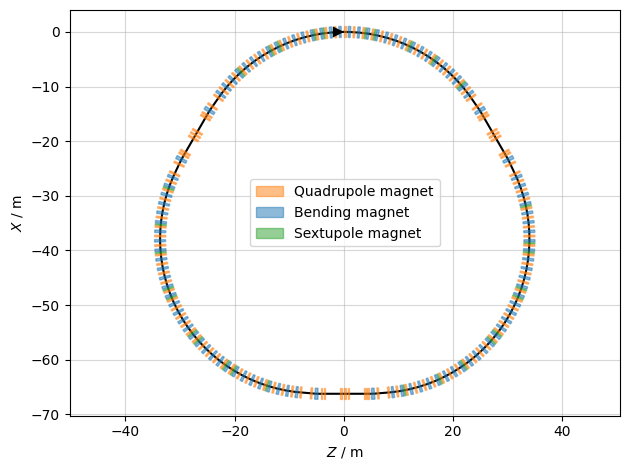

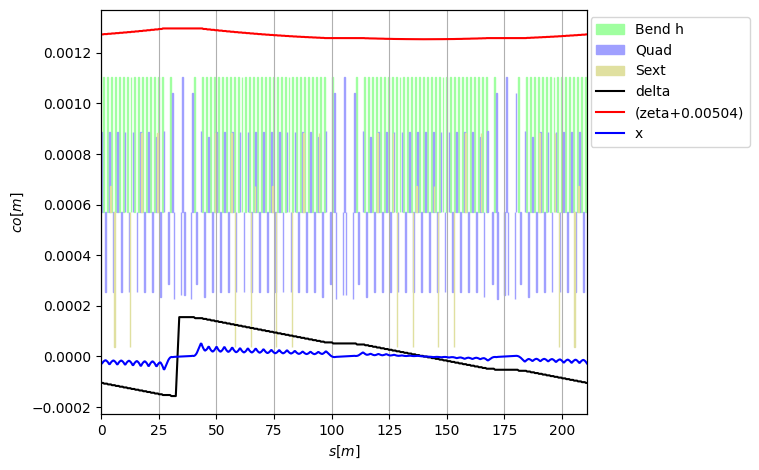

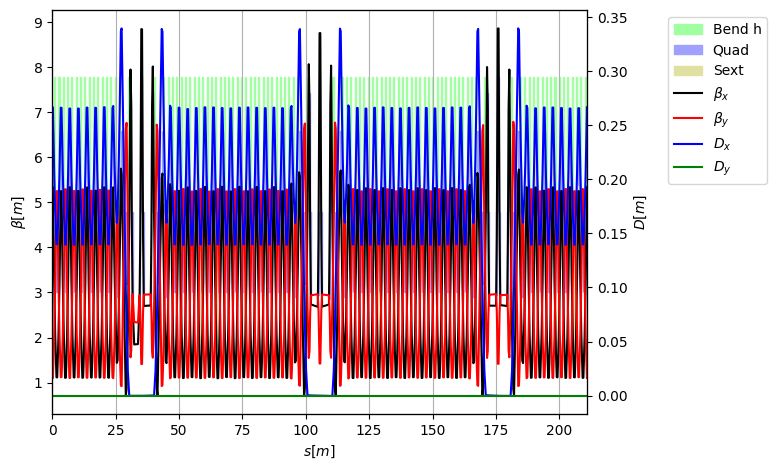

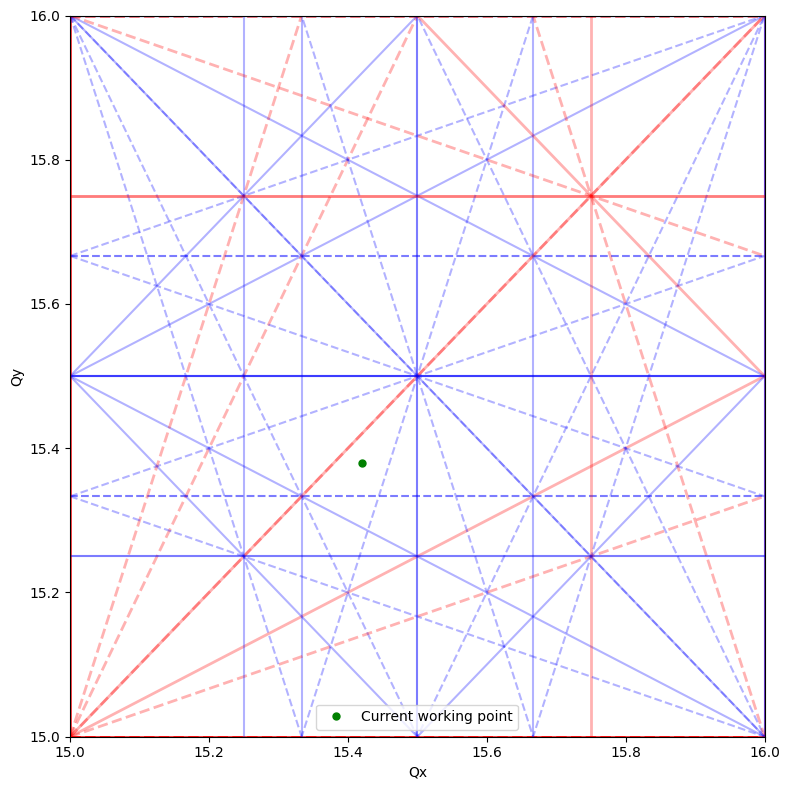

In [45]:

ring.survey().plot()
plt.tight_layout()
plt.savefig(f'design_{n}/plots/ring_survey_{n}.png')

ring_tw.plot(f'delta (zeta+0.00504) x')
plt.tight_layout()
plt.savefig(f'design_{n}/plots/ring_delta_{n}.png')

ring_tw.plot()
plt.tight_layout()
plt.savefig(f'design_{n}/plots/ring_twiss_{n}.png')


def calc_damping_time_constant(m):
    num=2*E0*ring_tw.T_rev0
    den=ring_tw.partition_numbers[m]*U0
    tau=num/den
    return tau

# Initialize the table
t = PrettyTable()
t.field_names = ["Parameter", "Value", "Unit"]
t.align["Parameter"] = "l"
t.align["Value"] = "r"

# Parameters
t.add_row([f"Horizontal Chromaticity (dqx)",f"{ring_tw.dqx:.4f}",''])
t.add_row([f"Vertical Chromaticity (dqy)",   f"{ring_tw.dqy:.4f}",''])
t.add_row([f"Max Betx", f"{max(ring_tw.betx):.2f}" ,"m"])
t.add_row([f"Max Bety", f"{max(ring_tw.bety):.2f}" ,"m"])
t.add_row(["Harmonic Number", f"{fRF/fRev:10.5f}", ""])
t.add_row(["RF Frequency", f"{fRF:8.5f}", "MHz"])
t.add_row(["Length of short drifts", f"{pdr['l_drift']:7.3f}", "m"])
t.add_row(["Circumference", f"{ring_tw.circumference:8.4f}", "m"])
t.add_row(["Revolution Time", f"{1e6*ring_tw.T_rev0:8.5f}", "us"])
t.add_row(["Energy Loss (Manual)", f"{U0:10.2f}", "keV"])
t.add_row(["Energy Loss (Twiss)", f"{ring_tw.eneloss_turn:10.2f}", "keV"])
t.add_row(["Vertical Damping Time", f"{1/ring_tw.damping_constants_turns[1]:10.3f}", "turns"])
t.add_row(["Horizontal Tune (qx)", f"{ring_tw.qx:10.5f}", ""])
t.add_row(["Vertical Tune (qy)", f"{ring_tw.qy:10.5f}", ""])
t.add_row(["Equilibrium Polarization", f"{ring_tw.spin_polarization_eq:8.5f}", ""])
t.add_row(["Equilibrium Emittance x", f"{ring_tw.eq_gemitt_x * 10e9}", "nm"])
t.add_row(["Equilibrium Emittance y", f"{ring_tw.eq_gemitt_y * 10e9}", "nm"])
t.add_row(["Polarization Build-up Time", f"{ring_tw.spin_t_pol_buildup_s:10.2f}", "s"])
t.add_row(["Horizontal Damping time constant ", f' {1/ring_tw.damping_constants_s[0]}',"s"])
t.add_row(["Vertical Damping time constant ", f'{1/ring_tw.damping_constants_s[1]}',"s"])
t.add_row(["Longitudinal Damping time constant ", f'{1/ring_tw.damping_constants_s[2]}',"s"])
t.add_row(["Horizontal Damping time constant (manual) ", f' {calc_damping_time_constant(0)}',"s"])
t.add_row(["Vertical Damping time constant (manual)", f'{calc_damping_time_constant(1)}',"s"])
t.add_row(["Longitudinal Damping time constant (manual)", f'{calc_damping_time_constant(2)}',"s"])
print(t)


#Working point plot
resonance_orders = (1,2,3,4)
Qx_range = (15,16)
Qy_range = (15,16)
resonances = resonance_lines(Qx_range,Qy_range,resonance_orders,3)
fig, ax = plt.subplots(1, figsize=(8,8), alpha=0.3)
ax.plot(ring_tw.qx, ring_tw.qy,'o', 
                color='green', label='Current working point', markersize=5)
ax.legend()
resonances.plot_resonance(fig)
plt.tight_layout()
plt.savefig(f'design_{n}/plots/working_point_{n}.png')

print('2nd order chrom x', ring_tw.ddqx)
print('2nd order chrom y', ring_tw.ddqy)

'l_cell':   3.4000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5000,
'dl_drift':  -0.1000,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   2.7000,
'l_trips':   0.4000,
'l_sext':   0.2000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.9478,
'kQDarc':  -2.9231,
'kQFarcM':   2.7828,
'kQDarcM':  -3.1021,
'kQFDS':   2.9748,
'kQDDS':  -2.6516,
'kQFDoub':   4.3741,
'kQDDoub':  -3.1934,
'kQFtr':   4.9561,
'kQDtr':  -3.0337,
'k2XF2arc': 143.4417,
'k2XD2arc': -243.1356,
'k2XF2arc2':  47.3454,
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_PRCH    Quadrupo  0.1500   0.0000   0.1500   0.0000  0.5000 'kQFarc' =  2.9478  
  Bend1_PR1   Bend      0.4000   0.6500   1.0500   0.5000  0.5000  None    =  0.0000  
  QDA_PR1     Quadrupo  0.3000   1.5500   1.8500   0.5000  0.5000 'kQDarc' = -2.9231  
  Bend2_PR1   Bend      0.4000   2.3500   2.7500   0.5000  0.5000  None    =  0.0000  
  QFA_PR1   

<Axes: >

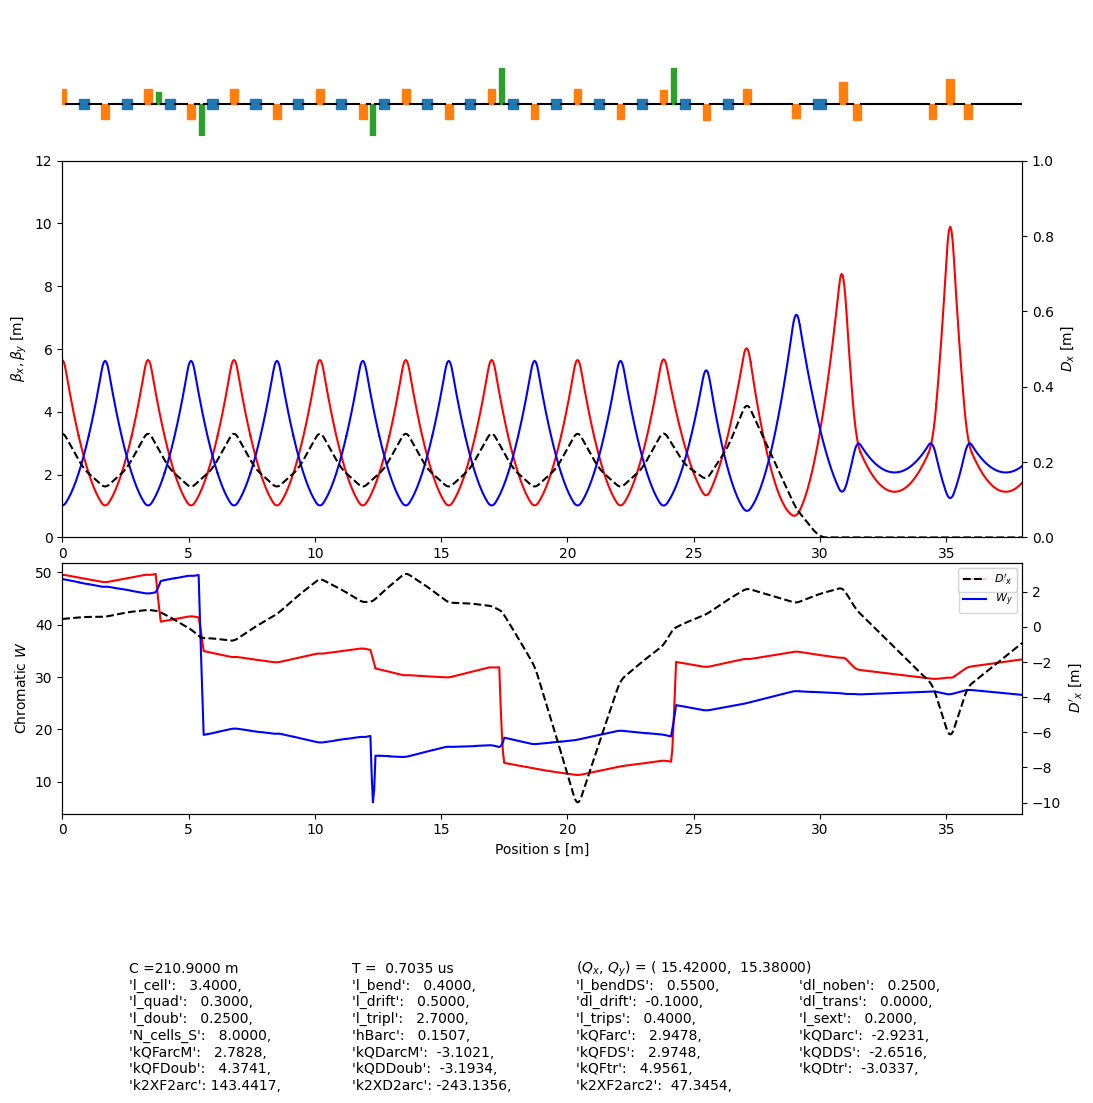

In [46]:
SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 12.), (0., 1.), .08, f"design_{n}/plots/Standard{n}.png" )

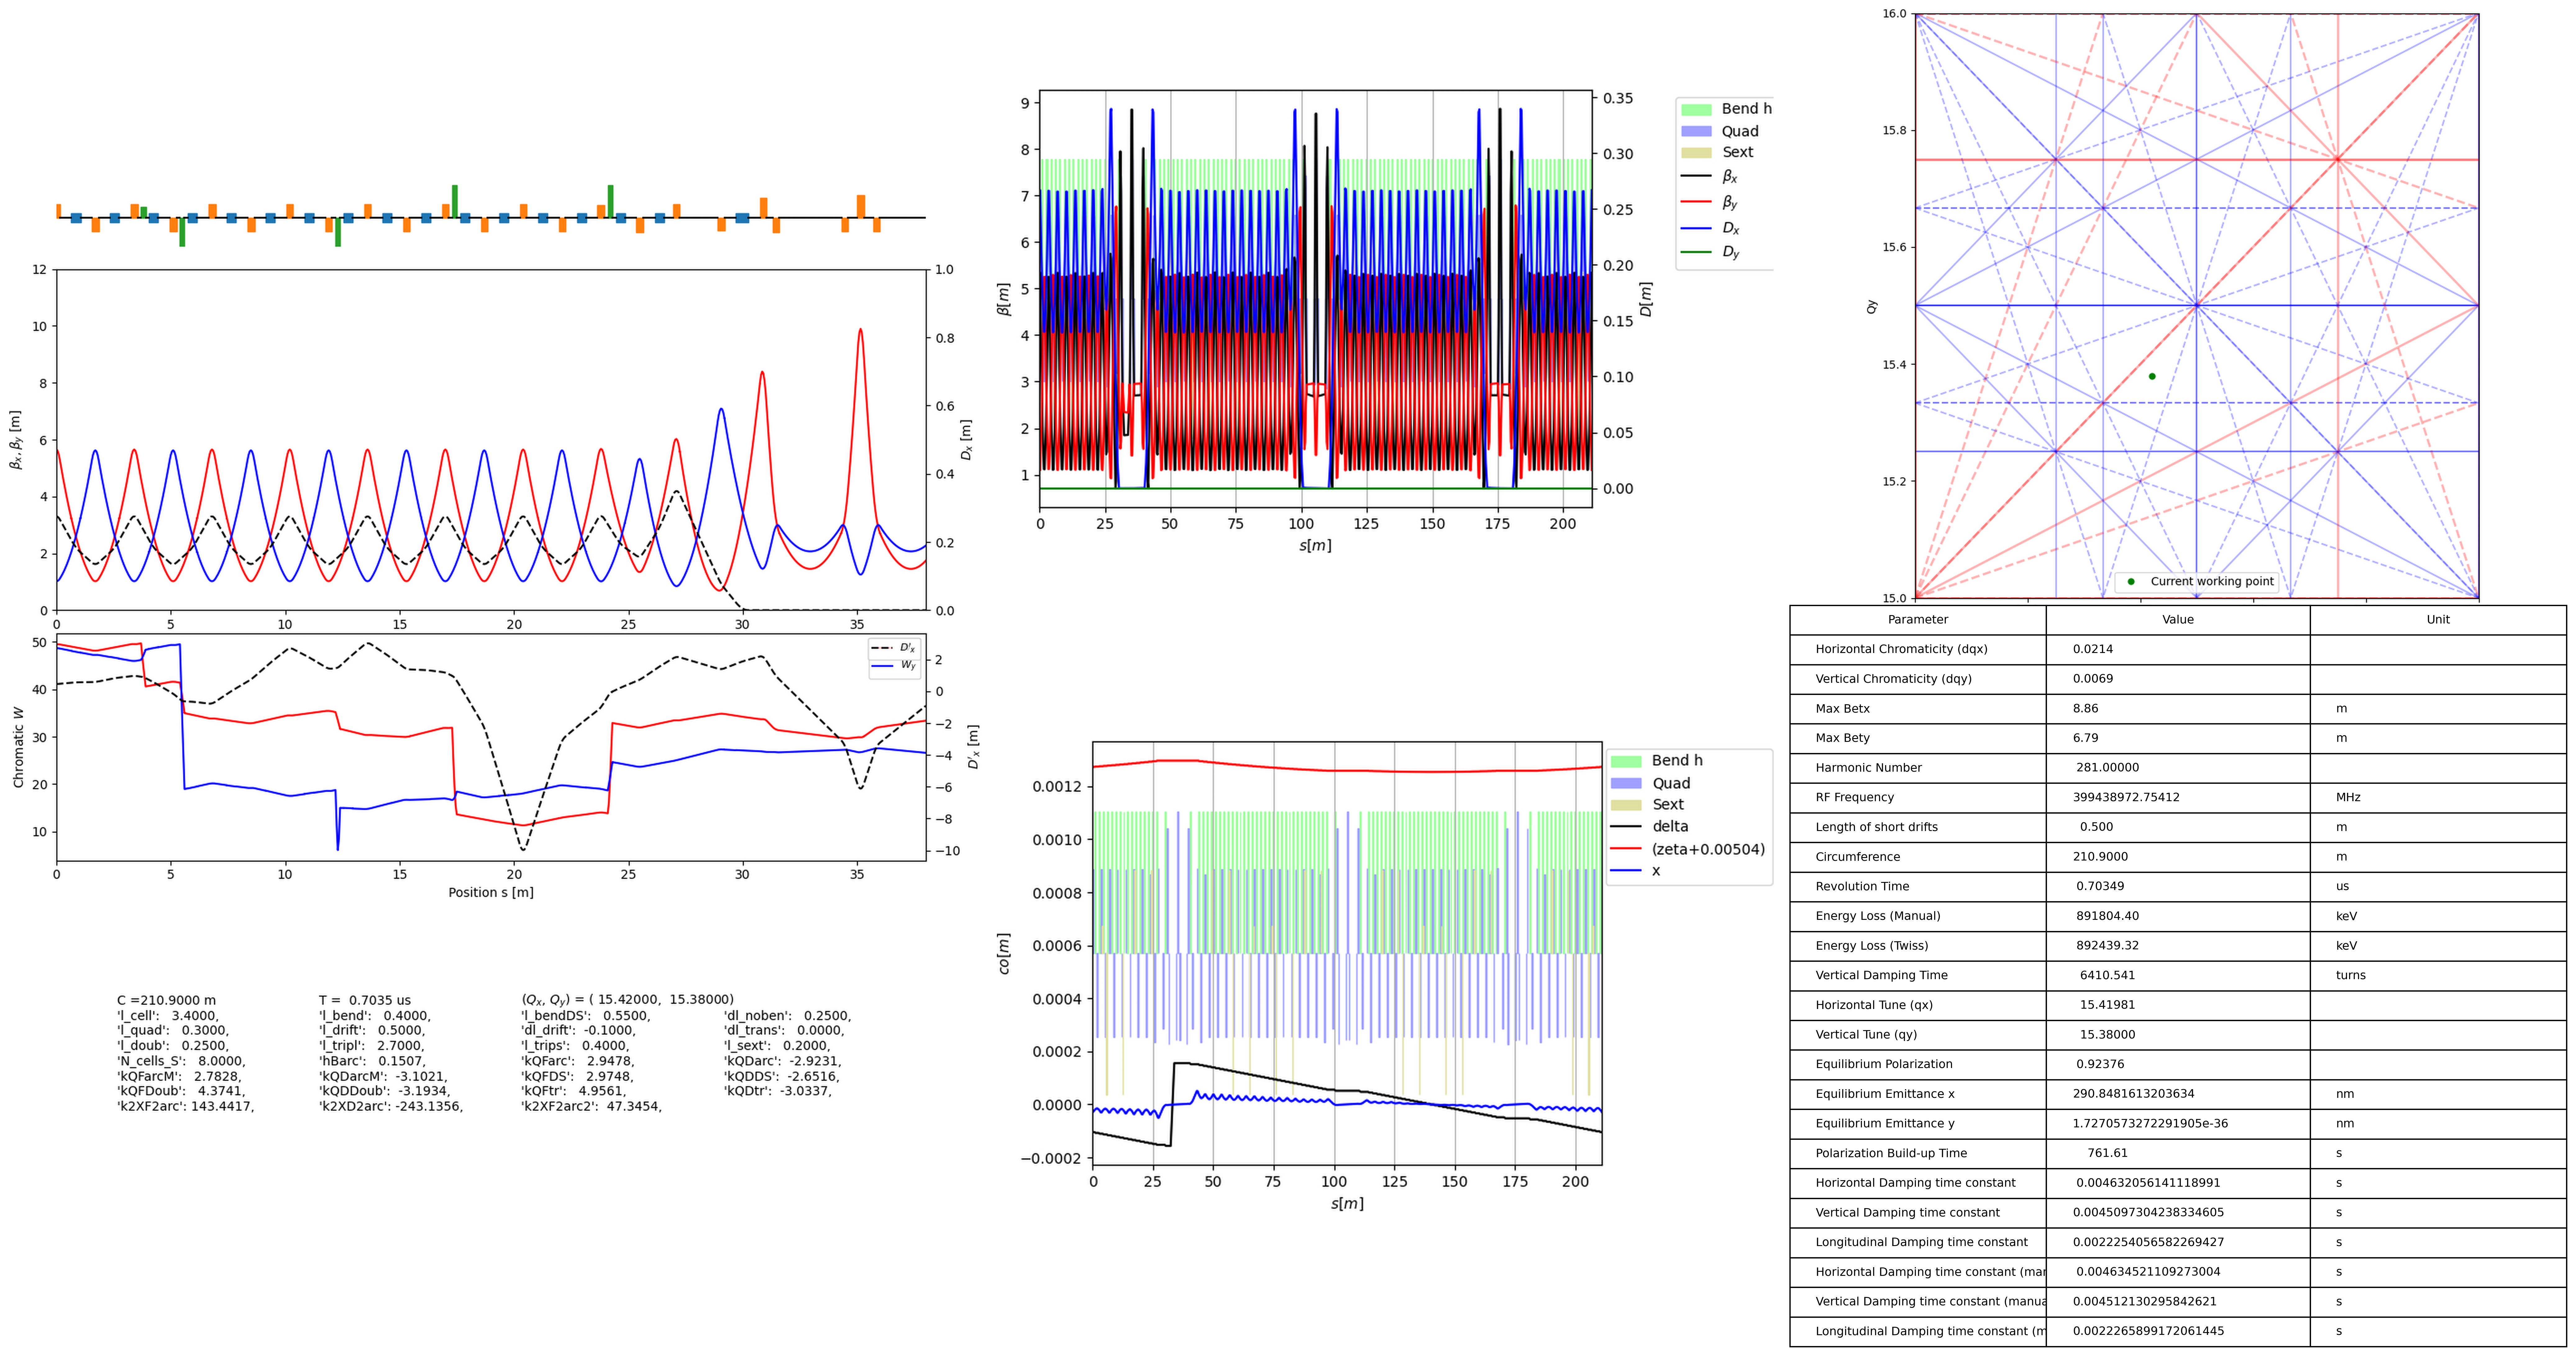

In [47]:
import io
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

def trim_whitespace(img, tolerance=0.95):
    """Removes white borders from a standard RGB image array."""
    if img.ndim == 3:
        mask = np.all(img > tolerance, axis=-1)
    else:
        mask = img > tolerance
    coords = np.argwhere(~mask)
    if coords.size == 0: return img
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def make_info_sheet_io(table_obj):
    # 1. Canvas setup
    fig = plt.figure(figsize=(28, 14), dpi=300, facecolor='white')
    
    # 2. Optimized GridSpec (3 rows, 3 columns)
    # We now use only 2 rows for the middle column since the ring is gone.
    # width_ratios: Left is wide, Middle is medium, Right (Table) is thin.
    gs = GridSpec(2, 3, figure=fig, 
                  width_ratios=[1.5, 1.2, 1.2], 
                  height_ratios=[1, 1],
                  hspace=0.05, wspace=0.02)

    img_paths = {
        "spuck": f"design_{n}/plots/Standard{n}.png",
        "delta": f"design_{n}/plots/ring_delta_{n}.png",
        "twiss": f"design_{n}/plots/ring_twiss_{n}.png",
        "wp": f"design_{n}/plots/working_point_{n}.png",
        "ring": f"design_{n}/plots/ring_survey_{n}.png"
    }

    def plot_img(ax_obj, path):
        try:
            if os.path.exists(path):
                img = mpimg.imread(path)
                img_cropped = trim_whitespace(img)
                ax_obj.imshow(img_cropped, aspect='equal', interpolation='lanczos')
            else:
                ax_obj.text(0.5, 0.5, f"File Not Found:\n{os.path.basename(path)}", 
                            ha='center', va='center', color='red')
        except Exception as e:
            ax_obj.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center')
        ax_obj.axis('off')

    # --- PLACEMENT ---
    
    # Left Column: Spuck (Full height across both rows)
    plot_img(fig.add_subplot(gs[:, 0]), img_paths["spuck"])

    # Middle Column: Twiss on top, Delta on bottom (Now much larger)
    plot_img(fig.add_subplot(gs[0, 1]), img_paths["twiss"])
    plot_img(fig.add_subplot(gs[1, 1]), img_paths["delta"])

    # Right Column Top: Resonance Plot (WP)
    plot_img(fig.add_subplot(gs[0, 2]), img_paths["wp"])

    # Right Column Bottom: The Table
    ax_table = fig.add_subplot(gs[1, 2])
    ax_table.axis('off')

    data = [[str(item) for item in row[:3]] for row in table_obj._rows]
    
    the_table = ax_table.table(
        cellText=data,
        colLabels=["Parameter", "Value", "Unit"],
        loc='center',
        cellLoc='left',
        colWidths=[0.33, 0.34, 0.33]
    )

    the_table.auto_set_font_size(False)
    the_table.set_fontsize(9)
    the_table.scale(1.0, 1.5)

    #plot_img(fig.add_subplot(gs[0, 2]), img_paths["ring"])

    # 3. Final Margin Push
    plt.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
    
    plt.savefig(f"design_{n}/plots/Accelerator_Summary_design_{n}_WP({constants.WP}).png", bbox_inches='tight', dpi=150)
    plt.show()

# Execution
make_info_sheet_io(t)

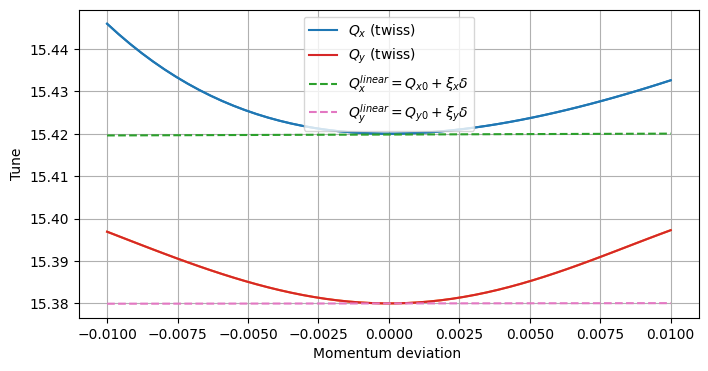

In [48]:
deltas = np.linspace(-1e-2,1e-2,50)

qx=[]
qy=[]
qx_shift=[]
qy_shift=[]
for d in deltas:
    ring.configure_radiation(model=None)
    tw=ring.twiss4d(delta0=d)
    qx.append(tw.qx)
    qy.append(tw.qy)

    qx_s=ring_tw.qx+ring_tw.dqx*d
    qx_shift.append(qx_s)
    qy_s=ring_tw.qy+ring_tw.dqy*d
    qy_shift.append(qy_s)



plt.figure(figsize=(8,4))
plt.plot(deltas,qx)
plt.plot(deltas, qy)    
plt.plot(deltas, qx, label='$Q_x$ (twiss)', color='tab:blue')
plt.plot(deltas, qy, label='$Q_y$ (twiss)', color='tab:red')

# Dotted/Dashed lines for the linear model
plt.plot(deltas, qx_shift, '--', label=f'$Q_x^{{linear}} = Q_{{x0}} + \\xi_x \\delta$', color='tab:green')
plt.plot(deltas, qy_shift, '--', label=f'$Q_y^{{linear}} = Q_{{y0}} + \\xi_y \\delta$', color='tab:pink')
plt.xlabel('Momentum deviation ')
plt.ylabel('Tune')
plt.legend()
plt.grid(True)
plt.savefig(f'design_{n}/plots/momentum_deviation{constants.WP}.png')

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/gq/lbmdkcnd6gl8bmr8gkyg9pz80000gn/T/ipykernel_67558/2717361793.py:10: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(nominal_tw.qx,nominal_tw.qy, 'ro', label='Nominal ($\delta=0$)')


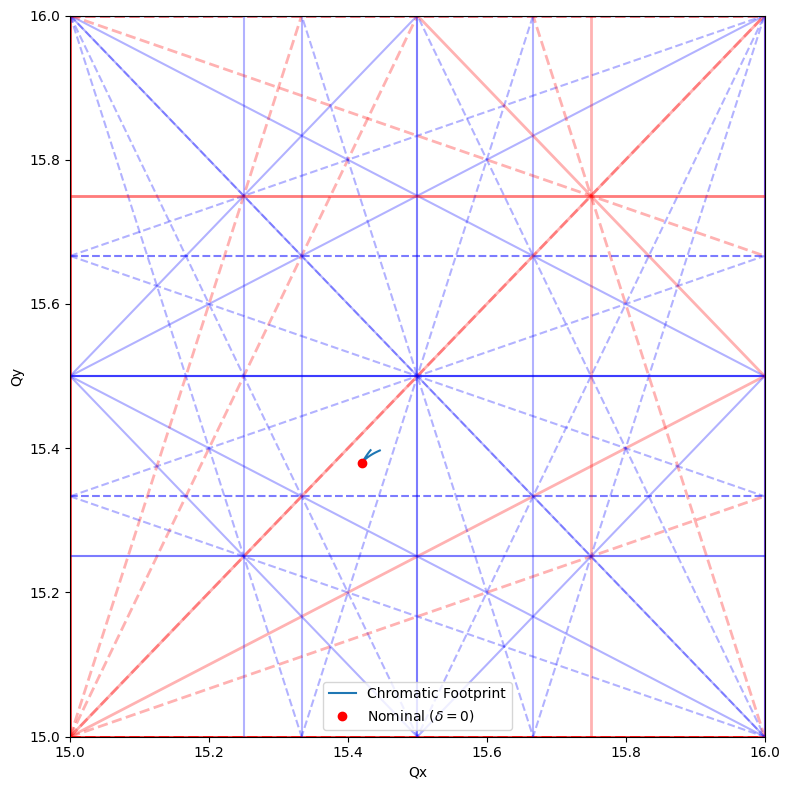

In [49]:

nominal_tw = ring.twiss4d(delta0=0)
'''Qx_range = (nominal_tw.qx-0.005,tw.qx+0.005)
Qy_range = (nominal_tw.qy-0.1,tw.qy+0.1)'''
resonances = resonance_lines(Qx_range,Qy_range,resonance_orders,3)
fig, ax = plt.subplots(1, figsize=(8,8), alpha=0.3)

ax.plot(qx, qy, label='Chromatic Footprint', color='tab:blue')

# Plot the actual center (delta=0)
ax.plot(nominal_tw.qx,nominal_tw.qy, 'ro', label='Nominal ($\delta=0$)')
ax.legend()
resonances.plot_resonance(fig)
plt.tight_layout()
plt.savefig(f'design_{n}/plots/momentum_dev_working_point_{n}.png')

In [50]:

coeffs_x = np.polyfit(deltas, qx, 2)
coeffs_y = np.polyfit(deltas, qy, 2)

Qpp_x = 2 * coeffs_x[0]
Qpp_y = 2 * coeffs_y[0]

print("Q''x =", Qpp_x)
print("Q''y =", Qpp_y)



Q''x = 381.8018629156474
Q''y = 351.6453102512061


In [51]:


line=ring
line.config.XTRACK_USE_EXACT_DRIFTS = True
xutil.set_integrator (line)
particle = 'positron'
operation_mode = 'z'
modes = {'z': 45.6e9, # in eV 
        'w': 80e9, # in eV
        'h': 120e9, # in eV 
        't': 182.5e9 # in eV
        }
energy = modes[operation_mode]


parameters = xutil.log_parameters (None, operation_mode, particle_type=particle, modes=modes)


# ## Choose a context
context = xo.ContextCpu()         # For CPU
context_tracking = xo.ContextCpu(omp_num_threads=0) # For CPU with activate multi-core CPU parallelization


# ## Transfer lattice on context and compile tracking code
# line.build_tracker(_context=context)

# line.configure_radiation(model='mean')
# line.compensate_radiation_energy_loss()

tw = line.twiss(eneloss_and_damping=True)

#xutil.update_reference_parameters_from_line (line, parameters, BS_scale_factor=0, update_type='all', max_bb_param=0)
# xutil.correct_parameters_conflicts(parameters, update_study_parameters_from_reference=False)

gamma0 = ring.particle_ref.gamma0[0]
beta0 = ring.particle_ref.beta0[0]

n_emittancex = 1.8e-6 * gamma0 * beta0

parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_DA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 10000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':13000e-6,
    'ini_cond_nemittance_y': 12000e-6,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


## Initial conditions
#particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)
particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])

## Tracking studies
line.configure_radiation(model='quantum')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xtrack/twiss.py:2096: RuntimeWarning: divide by zero encountered in divide
  damping_constants_turns * 2


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/2500 [00:00<?, ?it/s]

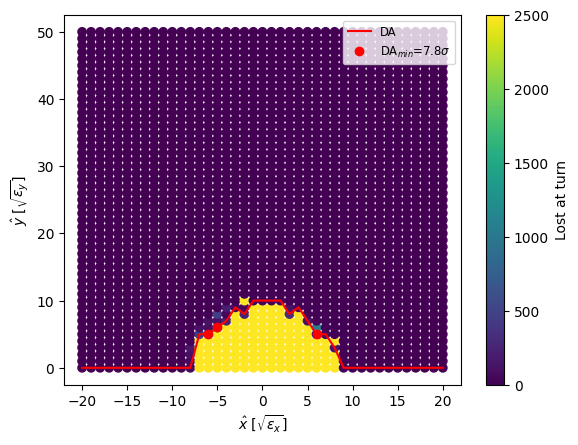

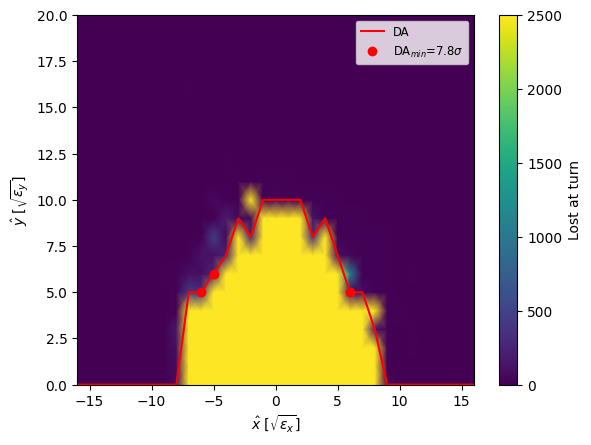

In [52]:
# dic_particles_all = xutil.tracking_data_process (tracking_data=line.record_last_track, 
#                             monitor_twiss=ring_tw.rows[0], 
#                             norm_emit_x=parameters['reference_parameters']['normalized_emittance_x'],
#                             norm_emit_y=parameters['reference_parameters']['normalized_emittance_y'],
#                             sigma_z=parameters['reference_parameters']['bunch_length'], 
#                             sigma_delta=parameters['reference_parameters']['energy_spread'],
#                             particle_id_to_use='all')
# xutil.save_dict_to_h5(f'{output_dir}/dic_particles_all.h5', dic_particles_all)



# liftime = my_xpf.particle_population_vs_turns (dic_particles_all['state'], T_rev0=tw.T_rev0)
# my_xpf.phase_space_evolution_difference (dic_particles_all['zeta'][:,0], dic_particles_all['delta'][:,0], dic_particles_all['zeta'][:,-1], dic_particles_all['delta'][:,-1], x_axis_label=r'$z~[m]$', y_axis_label=r'$\delta$')
# my_xpf.phase_space_evolution_difference (dic_particles_all['x'][:,0], dic_particles_all['px'][:,0], dic_particles_all['x'][:,-1], dic_particles_all['px'][:,-1], x_axis_label=r'$x~[m]$', y_axis_label=r'$px$')
# my_xpf.emittances_vs_turns (dic_particles_all['emit_x'], dic_particles_all['emit_y'], dic_particles_all['emit_zeta'], reference_emit_x=ref_param['emittance_x'], reference_emit_y=ref_param['emittance_y'], reference_emit_z=ref_param['energy_spread']*ref_param['bunch_length'], log_y_axis=True)
# my_xpf.coordinates_vs_turns (dic_particles_all['x_sigma'], dic_particles_all['px_sigma'], dic_particles_all['at_turn'], r'$x~[\sigma_x]$', r'$p_x~[\sigma_x]$', particle_id_list=dic_particles_all['particle_id_list'], full_init_cond=study_param['number_of_particles'])
# my_xpf.MA_vs_turns(particles, grid_details['num_r_y_points'], grid_details['num_delta'], grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
my_xpf.DA_vs_turns(particles, grid_details['num_r_y_points'], grid_details['num_theta_x_points'], grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
plt.xlim(-16,16)
plt.ylim(0,20)
plt.savefig(f"design_{n}/plots/DA_plot_{n}_WP{constants.WP}.png")

/Users/maddiewatson/Library/CloudStorage/OneDrive-Personal/University/Research year/polarizer-ring-studies/Essentials/xutil_DA_CC/xsuite_utilities.py:4333: RuntimeWarning: divide by zero encountered in divide
  delta_s_dist_evol = delta_cor/np.sqrt(sigma_matrix[5,5,:])


0 / 2091
1 / 2091
2 / 2091
3 / 2091
4 / 2091
5 / 2091
6 / 2091
7 / 2091
8 / 2091
9 / 2091
10 / 2091
11 / 2091
12 / 2091
13 / 2091
14 / 2091
15 / 2091
16 / 2091
17 / 2091
18 / 2091
19 / 2091
20 / 2091
21 / 2091
22 / 2091
23 / 2091
24 / 2091
25 / 2091
26 / 2091
27 / 2091
28 / 2091
29 / 2091
30 / 2091
31 / 2091
32 / 2091
33 / 2091
34 / 2091
35 / 2091
36 / 2091
37 / 2091
38 / 2091
39 / 2091
40 / 2091
41 / 2091
42 / 2091
43 / 2091
44 / 2091
45 / 2091
46 / 2091
47 / 2091
48 / 2091
49 / 2091
50 / 2091
51 / 2091
52 / 2091
53 / 2091
54 / 2091
55 / 2091
56 / 2091
57 / 2091
58 / 2091
59 / 2091
60 / 2091
61 / 2091
62 / 2091
63 / 2091
64 / 2091
65 / 2091
66 / 2091
67 / 2091
68 / 2091
69 / 2091
70 / 2091
71 / 2091
72 / 2091
73 / 2091
74 / 2091
75 / 2091
76 / 2091
77 / 2091
78 / 2091
79 / 2091
80 / 2091
81 / 2091
82 / 2091
83 / 2091
84 / 2091
85 / 2091
86 / 2091
87 / 2091
88 / 2091
89 / 2091
90 / 2091
91 / 2091
92 / 2091
93 / 2091
94 / 2091
95 / 2091
96 / 2091
97 / 2091
98 / 2091
99 / 2091
100 / 2091

NameError: name 'rp' is not defined

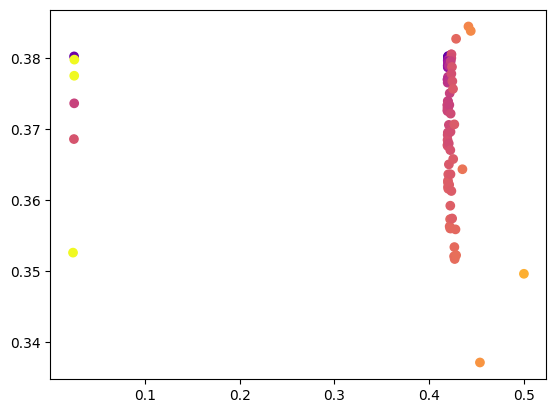

In [53]:

tracking_data=xutil.tracking_data_process (tracking_data=line.record_last_track, 
                            #monitor_twiss=tw.rows[0], 
                            norm_emit_x=parameters['reference_parameters']['normalized_emittance_x'],
                            norm_emit_y=parameters['reference_parameters']['normalized_emittance_y'],
                            sigma_z=parameters['reference_parameters']['bunch_length'], 
                            sigma_delta=parameters['reference_parameters']['energy_spread'],
                            particle_id_to_use='all')

Qx_start = xutil.nafflib_tune_calculation(tracking_data['x'][:, :1000], pq_coordinates=tracking_data['px'][:, :1000], number_harmonics=1)
Qy_start = xutil.nafflib_tune_calculation(tracking_data['y'][:, :1000], pq_coordinates=tracking_data['py'][:, :1000], number_harmonics=1)

# Window 2: Last 1000 turns (e.g., from turn 1000 to 2000)
Qx_end = xutil.nafflib_tune_calculation(tracking_data['x'][:, 1500:2500], pq_coordinates=tracking_data['px'][:, 1500:2500], number_harmonics=1)
Qy_end = xutil.nafflib_tune_calculation(tracking_data['y'][:, 1500:2500], pq_coordinates=tracking_data['py'][:, 1500:2500], number_harmonics=1)



my_xpf.tune_diffusion (Qx_start['Q1'], Qx_end['Q1'], Qy_start['Q1'], Qy_end['Q1'], initial_conditions_x_axis=grid_details['x_normalized'], initial_conditions_y_axis=grid_details['y_normalized'], xlabel='x [m]', ylabel='y [m]', resonance_orders=(1,2,3,4), annotate=False, delta_value= None)

In [ ]:
line.configure_radiation(model=None)

parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_MA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 1000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':13000e-6,
    'ini_cond_nemittance_y': 12000e-6,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


## Initial conditions
#particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)
particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])
print(grid_details)

## Tracking studies
line.configure_radiation(model='quantum')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


/home/mwatson/.local/lib/python3.12/site-packages/xtrack/twiss.py:2107: RuntimeWarning: divide by zero encountered in divide
  damping_constants_turns * 2


{'num_theta_x_points': 1, 'num_r_y_points': 31, 'num_delta': 51, 'num_particles': 1581, 'x_normalized': array([ 0.        ,  0.70710678,  1.41421356, ..., 19.79898987,
       20.50609665, 21.21320344]), 'y_normalized': array([ 0.        ,  0.70710678,  1.41421356, ..., 19.79898987,
       20.50609665, 21.21320344]), 'delta_init': array([-0.05, -0.05, -0.05, ...,  0.05,  0.05,  0.05])}
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking: 100%|██████████| 2500/2500 [01:33<00:00, 26.71it/s]


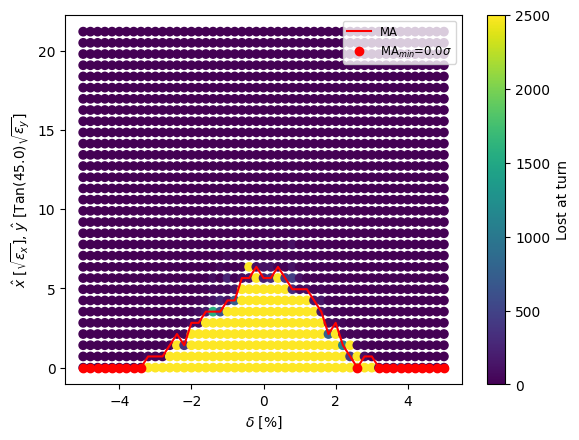

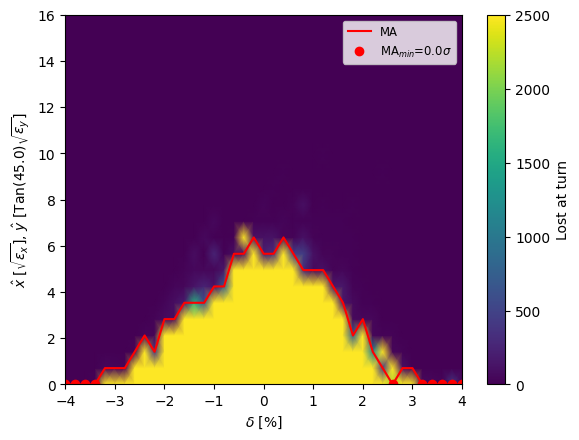

In [ ]:
my_xpf.MA_vs_turns(particles, grid_details['num_r_y_points'], 51, grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
plt.xlim(-4,4)
plt.ylim(0,16)
plt.savefig(f"design_{n}/plots/MA_plot_{n}_WP{constants.WP}.png")

In [ ]:
context = xo.ContextCpu(omp_num_threads=None)

# %% Simple test of tracking with synchrotron radiation - takes some time
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True)
#ring_tw.plot()
#print( ring_tw.keys() )
print( f' Energy loss per turn from twiss {ring_tw.eneloss_turn:10.2f} and me {U0:10.2f}')
print( 1/ring_tw.damping_constants_turns )
print( 2*E0/ring_tw.eneloss_turn )

npts = 200
epsx, epsy, epsl = 1.0e-7, 1.0e-7, 1.0e-4  # starting with somewhat large emittances
betxin, alfxin  = ring_tw.betx[0], ring_tw.alfx[0] 
xin, pxin       = ring_tw.x[0], ring_tw.px[0]
dxin, dpxin     = ring_tw.dx[0], ring_tw.dpx[0]
betyin, alfyin  = ring_tw.bety[0], ring_tw.alfy[0] 
yin, pyin       = ring_tw.y[0], ring_tw.py[0]   # should be zero for perfect case
#epsx, epsl      = 2.0*ring_tw.eq_gemitt_x, 2.0*ring_tw.eq_gemitt_zeta
betlin          = ring_tw.bets0
zetain, deltain = ring_tw.zeta[0], ring_tw.delta[0]
print( f'At reference location: D ={dxin:7.4f} m, Dp ={dpxin:7.4f},' +
       f' betx ={betxin:7.4f} m, alfx ={alfxin:7.4f},' + 
       f' betl ={betlin:7.4f} m ')

normat = np.array([
    [(epsx*betxin)**.5,         0,                 0,  0, 0, dxin*(epsl/betlin)**.5],
    [-alfxin*(epsx/betxin)**.5, (epsx/betxin)**.5, 0,  0, 0, dpxin*(epsl/betlin)**.5],
    [0,  0,  (epsx*betyin)**.5,         0,                 0, 0],
    [0,  0,  -alfyin*(epsx/betyin)**.5, (epsx/betyin)**.5, 0, 0],
    [0, 0, 0, 0, (epsl*betlin)**.5, 0                ],
    [0, 0, 0, 0, 0,                 (epsl/betlin)**.5]               
    ])

parts = np.array([
     [xin, pxin, yin, pyin, zetain, deltain] + normat@np.random.randn(6) 
         for ind in range(npts) ]).T
# quit()
p2 = xt.Particles(kinetic_energy0 = 2860.e6, mass0 = xt.ELECTRON_MASS_EV,
                  x    = parts[0], px   = parts[1],
                  y    = parts[2], py   = parts[3],
                  zeta = parts[4], delta = parts[5] )
ring.configure_radiation(model='quantum')
ring.track( p2, num_turns = 6100, turn_by_turn_monitor = True,
            with_progress = True )

data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]
#trnplt = range( len(data.x.T) ) # superimpose all turns, rendering is slowish
fig = plt.figure( figsize=(14., 4.) )
fig.suptitle( f'Phase Space Plots - particle survival {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
ax = fig.subplots(1, 3)
fig.subplots_adjust( wspace=0.4 )
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel("x' (mrad)")
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel("y' (mrad)")
ax[2].set_xlabel('z (mm)')
ax[2].set_ylabel(r'rel. mom. offset ($10^{-3}$)')
for ind in range( len(trnplt) ):  # data.x.T[ind] is nparray (behaviour of multiplication)!
   print( f' ==> Plotting turn"{trnplt[ind]:5d}')
   ax[0].scatter( 1000*(data.x.T[trnplt[ind]] - 1.*ring_tw.dx[0]*data.delta.T[trnplt[ind]]), 
            1000*(data.px.T[trnplt[ind]] - 1.*ring_tw.dpx[0]*data.delta.T[trnplt[ind]]),
            s=.4, c = f'C{ind:1d}')
   ax[1].scatter( 1000*(data.y.T[trnplt[ind]]), 1000*(data.py.T[trnplt[ind]]), 
            s=.2, c = f'C{ind:1d}' )
   ax[2].scatter(1000*data.zeta.T[trnplt[ind]], 1000*data.delta.T[trnplt[ind]], 
            s=.2, color=f'C{ind:1d}' )

print( [pdr['RFCav_1'].lag, pdr['RFCav_1'].voltage] )

print( f' Particle survival: {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
plt.savefig(f'design_{n}/plots/Particle_survival_{n}.png')

 Energy loss per turn from twiss  892439.34 and me  891804.40
[6584.4463899  6410.54107913 3163.37590209]
6409.399190679091
At reference location: D = 0.2667 m, Dp = 0.1206, betx = 5.3424 m, alfx =-2.3928, betl = 6.8862 m 


Tracking:  10%|▉         | 600/6100 [00:33<05:04, 18.07it/s]


KeyboardInterrupt: 